In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.4 MB/s eta 0:00:00


In [2]:
from google.colab import files
import os
import pandas as pd
from glob import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, random_split, DataLoader
from torchvision import transforms as T
import os
import torchmetrics
import timm
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "anshiagarwal",\r\n  "key": "KGAT_2759fd140ed93adc64471ec4436287bb"\r\n}\r\n'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d alifatahi/multi-class-neurological-disorder-mcnd-dataset

if not os.path.exists("/content/mcnd_dataset"):
  !unzip /content/multi-class-neurological-disorder-mcnd-dataset.zip -d /content/mcnd_dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/mcnd_dataset/Normal/C-S (330).png  
  inflating: /content/mcnd_dataset/Normal/C-S (331).png  
  inflating: /content/mcnd_dataset/Normal/C-S (332).png  
  inflating: /content/mcnd_dataset/Normal/C-S (333).png  
  inflating: /content/mcnd_dataset/Normal/C-S (334).png  
  inflating: /content/mcnd_dataset/Normal/C-S (335).png  
  inflating: /content/mcnd_dataset/Normal/C-S (336).png  
  inflating: /content/mcnd_dataset/Normal/C-S (337).png  
  inflating: /content/mcnd_dataset/Normal/C-S (338).png  
  inflating: /content/mcnd_dataset/Normal/C-S (339).png  
  inflating: /content/mcnd_dataset/Normal/C-S (34).png  
  inflating: /content/mcnd_dataset/Normal/C-S (340).png  
  inflating: /content/mcnd_dataset/Normal/C-S (341).png  
  inflating: /content/mcnd_dataset/Normal/C-S (342).png  
  inflating: /content/mcnd_dataset/Normal/C-S (343).png  
  inflating: /content/mcnd_dataset/Normal/C-S (344).png  
  inflating: /content/

In [5]:
torch.manual_seed(2025)

class Custom_Dataset(Dataset):
    def __init__(self, root, transformations = None, im_files = [".png", ".jpg", ".jpeg", ".bmp"]):
        self.transformations = transformations

        self.im_paths = []
        for i in im_files:
            self.im_paths.extend(glob(f"{root}/*/*{i}"))

        self.class_names, self.class_counts = {}, {}
        class_num = 0
        for path in self.im_paths:
            class_name = self.get_class(path)
            if class_name not in self.class_names:
                self.class_names[class_name] = class_num
                self.class_counts[class_name] = 1
                class_num += 1
            else:
                self.class_counts[class_name] += 1

    def get_class(self, path):
        return os.path.dirname(path).split("/")[-1]

    def __len__(self):
        return len(self.im_paths)

    def __getitem__(self, idx):
        path = self.im_paths[idx]
        img = Image.open(path).convert("RGB")
        label = self.class_names[self.get_class(path)]

        if self.transformations is not None:
            img = self.transformations(img)
        return img, label

    @classmethod
    def get_dls(cls, root, transformations, batch_size, split = [0.9, 0.05, 0.05], n_workers = 4):
        ds = cls(root = root, transformations = transformations)
        total_size = len(ds)

        train_size = int(total_size * split[0])
        val_size = int(total_size * split[1])
        test_size = total_size - (train_size + val_size)

        train_ds, val_ds, test_ds = random_split(ds, [train_size, val_size, test_size])

        train_dl = DataLoader(
            train_ds,
            batch_size = batch_size,
            shuffle = True,
            num_workers = n_workers
        )
        val_dl = DataLoader(
            val_ds,
            batch_size = batch_size,
            shuffle = False,
            num_workers = n_workers
        )
        test_dl = DataLoader(
            test_ds,
            batch_size = 1,
            shuffle = False,
            num_workers = n_workers
        )

        return train_dl, val_dl, test_dl, ds.class_names, ds.class_counts

root = "/content/mcnd_dataset"
mean, std, size, bs = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 128, 32
tfs = T.Compose([
    T.Resize((size, size)),
    T.ToTensor(),
    T.Normalize(mean, std)
])

train_dl, val_dl, test_dl, classes, class_counts = Custom_Dataset.get_dls(root=root, transformations=tfs, batch_size=bs)
print(len(train_dl))
print(len(val_dl))
print(len(test_dl))
print(classes)

462
26
820
{'Normal': 0, 'MS': 1, 'BT_glioma': 2, 'BT_meningioma': 3, 'AD_VeryMildDemented': 4, 'AD_MildDemented': 5, 'AD_ModerateDemented': 6, 'BT_pituitary': 7}


Data analysis is in process...



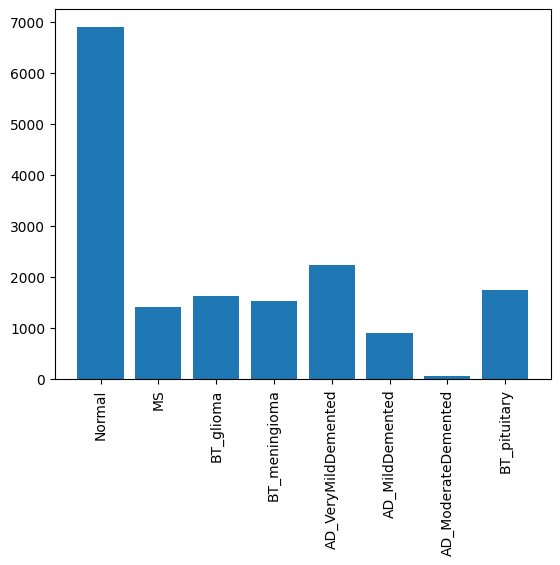

In [14]:
class Visualization:
    def __init__(self, vis_data, n_images, rows, cmap = None, class_names = None, class_counts = None, t_type = "rgb"):
        self.n_images = n_images
        self.t_type = t_type
        self.cmap = cmap
        self.class_names = class_names
        self.rows = rows
        self.class_counts = class_counts
        data_names = ["train", "val", "test"]
        self.vis_data = {data_names[i]: vis_data[i] for i in range(len(vis_data))}
        if isinstance(class_counts, list):
            self.analysis_datas = {data_names[i]: class_counts[i] for i in range(len(class_counts))}
        else:
            self.analysis_datas = {"all": class_counts}

    def tensors_to_images(self, t):
        gray_tfs = T.Compose([
            T.Normalize(mean = [0.], std = [1/0.5]),
            T.Normalize(mean = [-0.5], std = [1])
        ])
        rgb_tfs = T.Compose([
            T.Normalize(mean = [0., 0., 0.], std = [1/0.229, 1/0.224, 1/0.225]),
            T.Normalize(mean = [-0.485, -0.456, -0.406], std = [1., 1., 1.])
        ])

        if self.t_type == "rgb":
            inv_trans = rgb_tfs
        else:
            inv_trans = gray_tfs

        return (inv_trans(t) * 255).detach().squeeze().cpu().permute(1, 2, 0).numpy().astype(np.uint8) if self.t_type == "gray" else (inv_trans(t) * 255).detach().cpu().permute(1, 2, 0).numpy().astype(np.uint8)

    def plot(self, rows, cols, count, im, title = "Original_image"):
        plt.subplot(rows, cols, count)
        plt.imshow(self.tensors_to_images(im))
        plt.axis("off")
        plt.title(title)
        return count + 1

    def visualize(self, data, name):
        print(f"{name.upper()} Data Visualization is in process...\n")
        assert self.cmap in ["rgb", "gray"], "Please choose rgb or gray cmap"

        cmap = "viridis" if self.cmap =="rgb" else None
        cols = self.n_images // self.rows
        count = 1
        plt.figure(figsize = (20, 20))
        indices = [np.random.randint(0, len(data) - 1) for _ in range(self.n_images)]
        for idx, index in enumerate(indices):
            if count == self.n_images + 1:
                break
            image, label = data.dataset[index]
            plt.subplot(self.rows, cols, idx+1)
            if cmap:
                plt.imshow(self.tensors_to_images(image), cmap = cmap)
            else:
                plt.imshow(self.tensors_to_images(image))
            plt.axis("off")
            if self.class_names is not None:
                plt.title(f"GT -> {self.class_names[int(label)]}")
            else:
                plt.title(f"GT -> {label}")

        plt.show()

    def data_analysis(self, class_counts, name):
        print("Data analysis is in process...\n")
        plt.bar(class_counts.keys(), class_counts.values())
        plt.xticks(rotation=90)
        plt.show()

    def plot_pie(self, class_counts):
        print("Generating pie chart...\n")
        plt.figure(figsize=(8, 8))
        plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
        plt.title("Class Distribution")
        plt.axis("equal")
        plt.show()

    def visualization(self): [self.visualize(data.dataset, save_name) for (save_name, data) in self.vis_data.items()]

    def analysis(self): [self.data_analysis(data, save_name) for (save_name, data) in self.analysis_datas.items()]

    def pie_chart(self): [self.plot_pie(data) for data in self.analysis_datas.values()]


vis = Visualization(vis_data = [train_dl, val_dl, test_dl], n_images = 18, rows = 6, cmap = "rgb", class_names = list(classes.keys()), class_counts = class_counts)
vis.analysis()

Generating pie chart...



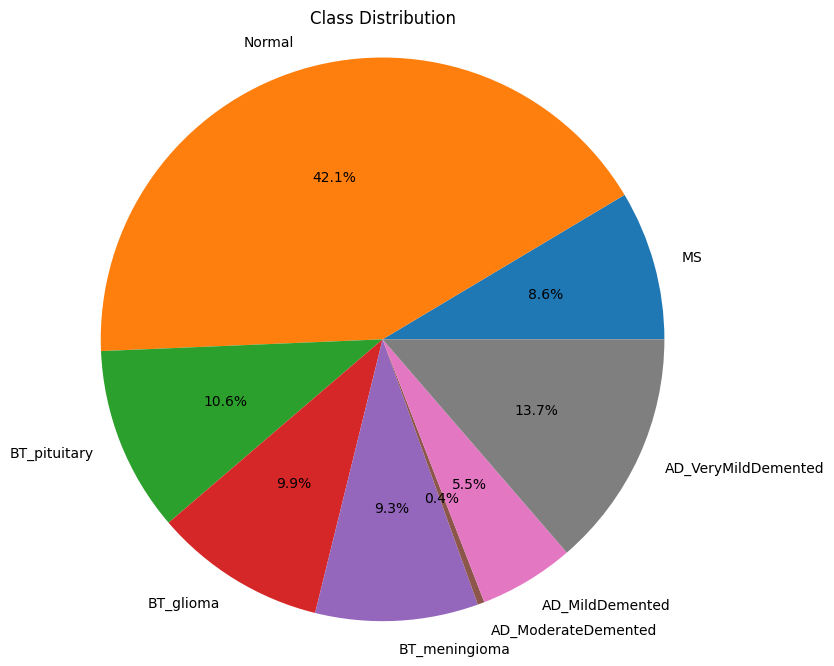

In [ ]:
vis.pie_chart()

In [ ]:
vis.visualization()

Output hidden; open in https://colab.research.google.com to view.

In [15]:

class TrainValidation:
    def __init__(self, model_name, classes, train_dl, val_dl, device, save_dir = "/content/saved_models", save_prefix = "model", lr = 3e-4, epochs = 50, patience = 5, threshold = 0.01, dev_mode = False):
        self.model_name = model_name
        self.classes = classes
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.device = device
        self.save_dir = save_dir
        self.save_prefix = save_prefix
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.threshold = threshold
        self.dev_mode = dev_mode
        self.model = timm.create_model(
            model_name,
            pretrained = True,
            num_classes = len(classes)
        ).to(self.device)

        self.loss_fxns = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr = self.lr)
        self.f1_metric = torchmetrics.F1Score(
            task = "multiclass",
            num_classes = len(classes)
        ).to(self.device)
        os.makedirs(save_dir, exist_ok = True)
        self.best_loss = float("inf")
        self.best_acc = 0
        self.not_improved = 0
        self.train_losses  = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_f1s = []
        self.val_f1s = []

    @staticmethod
    def to_device(batch, device):
        images, labels = batch
        return images.to(device), labels.to(device)

    def train_model(self):
        self.model.train()
        train_loss, train_acc, train_f1 = 0, 0, 0
        self.f1_metric.reset()

        pbar = tqdm(enumerate(self.train_dl), desc="Training")
        for idx, batch in pbar:
            if self.dev_mode and idx == 1:
                break
            images, labels = self.to_device(batch, self.device)
            preds = self.model(images)
            loss = self.loss_fxns(preds, labels)

            self.optimizer.zero_grad() # forget
            loss.backward()            # update
            self.optimizer.step()      # take step

            train_loss += loss.item()
            train_acc += (torch.argmax(preds, dim = 1) == labels).sum().item()

            self.f1_metric.update(preds, labels)

            batch_acc = (torch.argmax(preds, dim=1) == labels).float().mean().item()
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc":  f"{batch_acc:.4f}"
            })

        train_loss /= len(self.train_dl)
        train_acc /= len(self.train_dl.dataset)
        train_f1 = self.f1_metric.compute().item()

        self.train_losses.append(train_loss)
        self.train_accuracies.append(train_acc)
        self.train_f1s.append(train_f1)

        return train_loss, train_acc, train_f1

    def validate_model(self):
        self.model.eval() #evaluate
        val_loss, val_acc = 0.0, 0.0
        self.f1_metric.reset()

        with torch.no_grad():
            pbar = tqdm(enumerate(self.val_dl), desc = "validation")
            for idx, batch in pbar:
                if self.dev_mode and idx == 1:
                    break

                images, labels = self.to_device(batch, self.device)
                preds = self.model(images)
                loss = self.loss_fxns(preds, labels)

                val_loss += loss.item()
                val_acc += (torch.argmax(preds, dim = 1) == labels).sum().item()

                self.f1_metric.update(preds, labels)

                batch_acc = (torch.argmax(preds, dim=1) == labels).float().mean().item()
                pbar.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "acc":  f"{batch_acc:.4f}"
                })

        val_loss /= len(self.val_dl)
        val_acc /= len(self.val_dl.dataset)
        val_f1 = self.f1_metric.compute().item()

        self.val_losses.append(val_loss)
        self.val_accuracies.append(val_acc)
        self.val_f1s.append(val_f1)

        return val_loss, val_acc, val_f1

    def save_best_model(self, val_f1, val_loss):
        if val_f1 > self.best_acc + self.threshold:
            self.best_acc = val_f1
            save_path = os.path.join(self.save_dir, f"{self.save_prefix}_best_acc.pth")
            torch.save(self.model.state_dict(), save_path)
            print(f"Best model saved with F1-Score: {self.best_acc:.3f}")
            self.not_improved = 0
        else:
            self.not_improved += 1
            print(f"No improvement for {self.not_improved} epoch(s).")

    def run(self):
        print("----------------Start Training----------------")

        for epoch in range(self.epochs):
            if self.dev_mode and epoch == 1:
                break

            print(f"Epoch {epoch + 1}/{self.epochs}")

            train_loss, train_acc, train_f1 = self.train_model()
            val_loss, val_acc, val_f1 = self.validate_model()

            self.save_best_model(val_f1, val_loss)

            if self.not_improved >= self.patience:
                print(f"Early stopping at epoch {epoch + 1}.")
                break


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [18]:
model_name = "rexnet_150"
save_prefix = "rexnet_model"
save_dir = "/content/drive/MyDrive/MRI_Project/saved_models"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
trainer = TrainValidation(
    model_name = model_name,
    device = device,
    save_dir = save_dir,
    save_prefix = save_prefix,
    classes = classes,
    patience = 3,
    train_dl = train_dl,
    val_dl = val_dl,
    dev_mode = False
)

trainer.run()

----------------Start Training----------------
Epoch 1/50


Training: 462it [00:56,  8.15it/s, loss=0.1880, acc=0.8750]
validation: 26it [00:03,  8.31it/s, loss=0.3258, acc=0.8500]


Best model saved with F1-Score: 0.867
Epoch 2/50


Training: 462it [00:49,  9.37it/s, loss=0.7576, acc=0.8750]
validation: 26it [00:02,  9.99it/s, loss=0.0562, acc=1.0000]


Best model saved with F1-Score: 0.918
Epoch 3/50


...

No improvement for 1 epoch(s).
Epoch 5/50



Training: 462it [00:53,  8.58it/s, loss=0.8634, acc=0.8750]
validation: 26it [00:03,  8.06it/s, loss=0.3417, acc=0.9000]


No improvement for 2 epoch(s).
Epoch 6/50


Training: 462it [00:51,  9.00it/s, loss=0.0779, acc=1.0000]
validation: 26it [00:02, 10.13it/s, loss=0.0087, acc=1.0000]

No improvement for 3 epoch(s).
Early stopping at epoch 6.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
metrics = {
    "train_losses": trainer.train_losses,
    "val_losses": trainer.val_losses,
    "train_accuracies": trainer.train_accuracies,
    "val_accuracies": trainer.val_accuracies,
    "train_f1s": trainer.train_f1s,
    "val_f1s": trainer.val_f1s
}

torch.save(metrics, f"{save_dir}/training_metrics.pth")

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    model_name = "rexnet_150",
    pretrained = "False",
    num_classes = len(classes)
).to(device)

In [22]:
model_path = "/content/drive/MyDrive/MRI_Project/saved_models/rexnet_model_best_acc.pth"

model.load_state_dict(torch.load(model_path, map_location = device))
model.eval()

RexNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (features): Sequential(
    (0): LinearBottleneck(
      (conv_dw): ConvNormAct(
        (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
      (act_dw): ReLU6()
      (conv_pwl): ConvNormAct(
        (conv): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (1): LinearBottlene

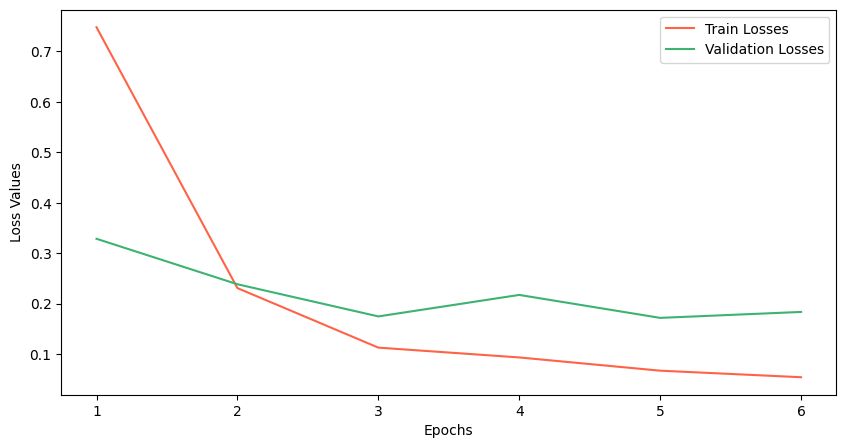

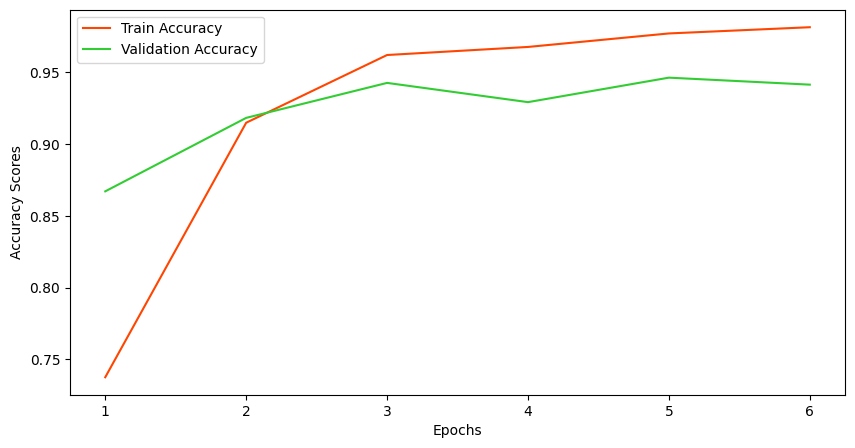

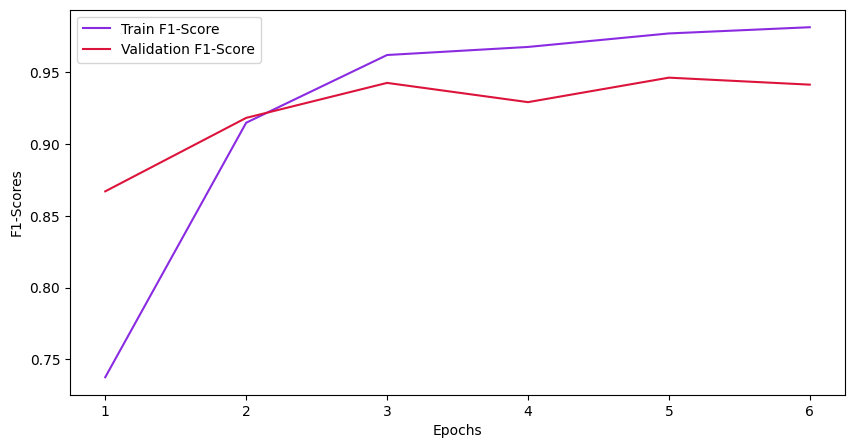

In [29]:
class plot_learning:
    def __init__ (self, train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s):
        self.train_losses = train_losses
        self.val_losses = val_losses
        self.train_accuracies = train_accuracies
        self.val_accuracies = val_accuracies
        self.train_f1s = train_f1s
        self.val_f1s = val_f1s

    def plot(self, arr_1, arr_2, label_1, label_2, color_1, color_2):
        plt.plot(arr_1, label = label_1, color = color_1)
        plt.plot(arr_2, label = label_2, color = color_2)

    def create_figure(self):
        plt.figure(figsize = (10, 5))

    def decorate(self, y_label, x_label = "Epochs"):
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.xticks(ticks = np.arange(len(self.val_accuracies)), labels = [i for i in range(1, len(self.train_accuracies)+1)])
        plt.legend()
        plt.show()

    def visualize(self):
        self.create_figure()
        self.plot(arr_1 = self.train_losses, arr_2 = self.val_losses, label_1 = "Train Losses", label_2 = "Validation Losses", color_1 = "#FF6347", color_2 = "#3CB371")
        self.decorate(y_label = "Loss Values")

        self.create_figure()
        self.plot(arr_1 = self.train_accuracies, arr_2 = self.val_accuracies, label_1 = "Train Accuracy", label_2 = "Validation Accuracy", color_1 = "#FF4500", color_2 = "#32CD32")
        self.decorate(y_label = "Accuracy Scores")

        self.create_figure()
        self.plot(arr_1 = self.train_f1s, arr_2 = self.val_f1s, label_1 = "Train F1-Score", label_2 = "Validation F1-Score", color_1 = "#8A2BE2", color_2 = "#DC143C")
        self.decorate(y_label = "F1-Scores")

metrics = torch.load(f"{save_dir}/training_metrics.pth")

plot_learning(
    train_losses = metrics["train_losses"],
    val_losses = metrics["val_losses"],
    train_accuracies = metrics["train_accuracies"],
    val_accuracies = metrics["val_accuracies"],
    train_f1s = metrics["train_f1s"],
    val_f1s = metrics["val_f1s"]
).visualize()


In [30]:
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            scores = model(images)
            predictions = torch.argmax(scores, dim = 1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

test_acc = evaluate(model, test_dl, device)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9329


In [31]:
# explainable

!pip install grad-cam==1.4.6
import cv2, random
import seaborn as sns
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.4.6-py3-none-any.whl size=38340 sha256=db44ee583f5d088cb70dc345a76b0e337739f38bd64cf717cc5ea3eafe95691f
  Stored in directory: /root/.cache/pip/wheels/02/26/f1/92ac7f7699f6f0849e03e212b8b0bb8d2c3d7b2723aa474b22
Successfully built grad-cam


In [42]:
class Denormalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        for channel, mean, std in zip(tensor, self.mean, self.std):
            channel.mul_(std).add_(mean)
        return tensor

Inference: 820it [00:13, 59.59it/s]


Accuracy of model on test data --> 0.933
F1 score of model on test data -> 0.933


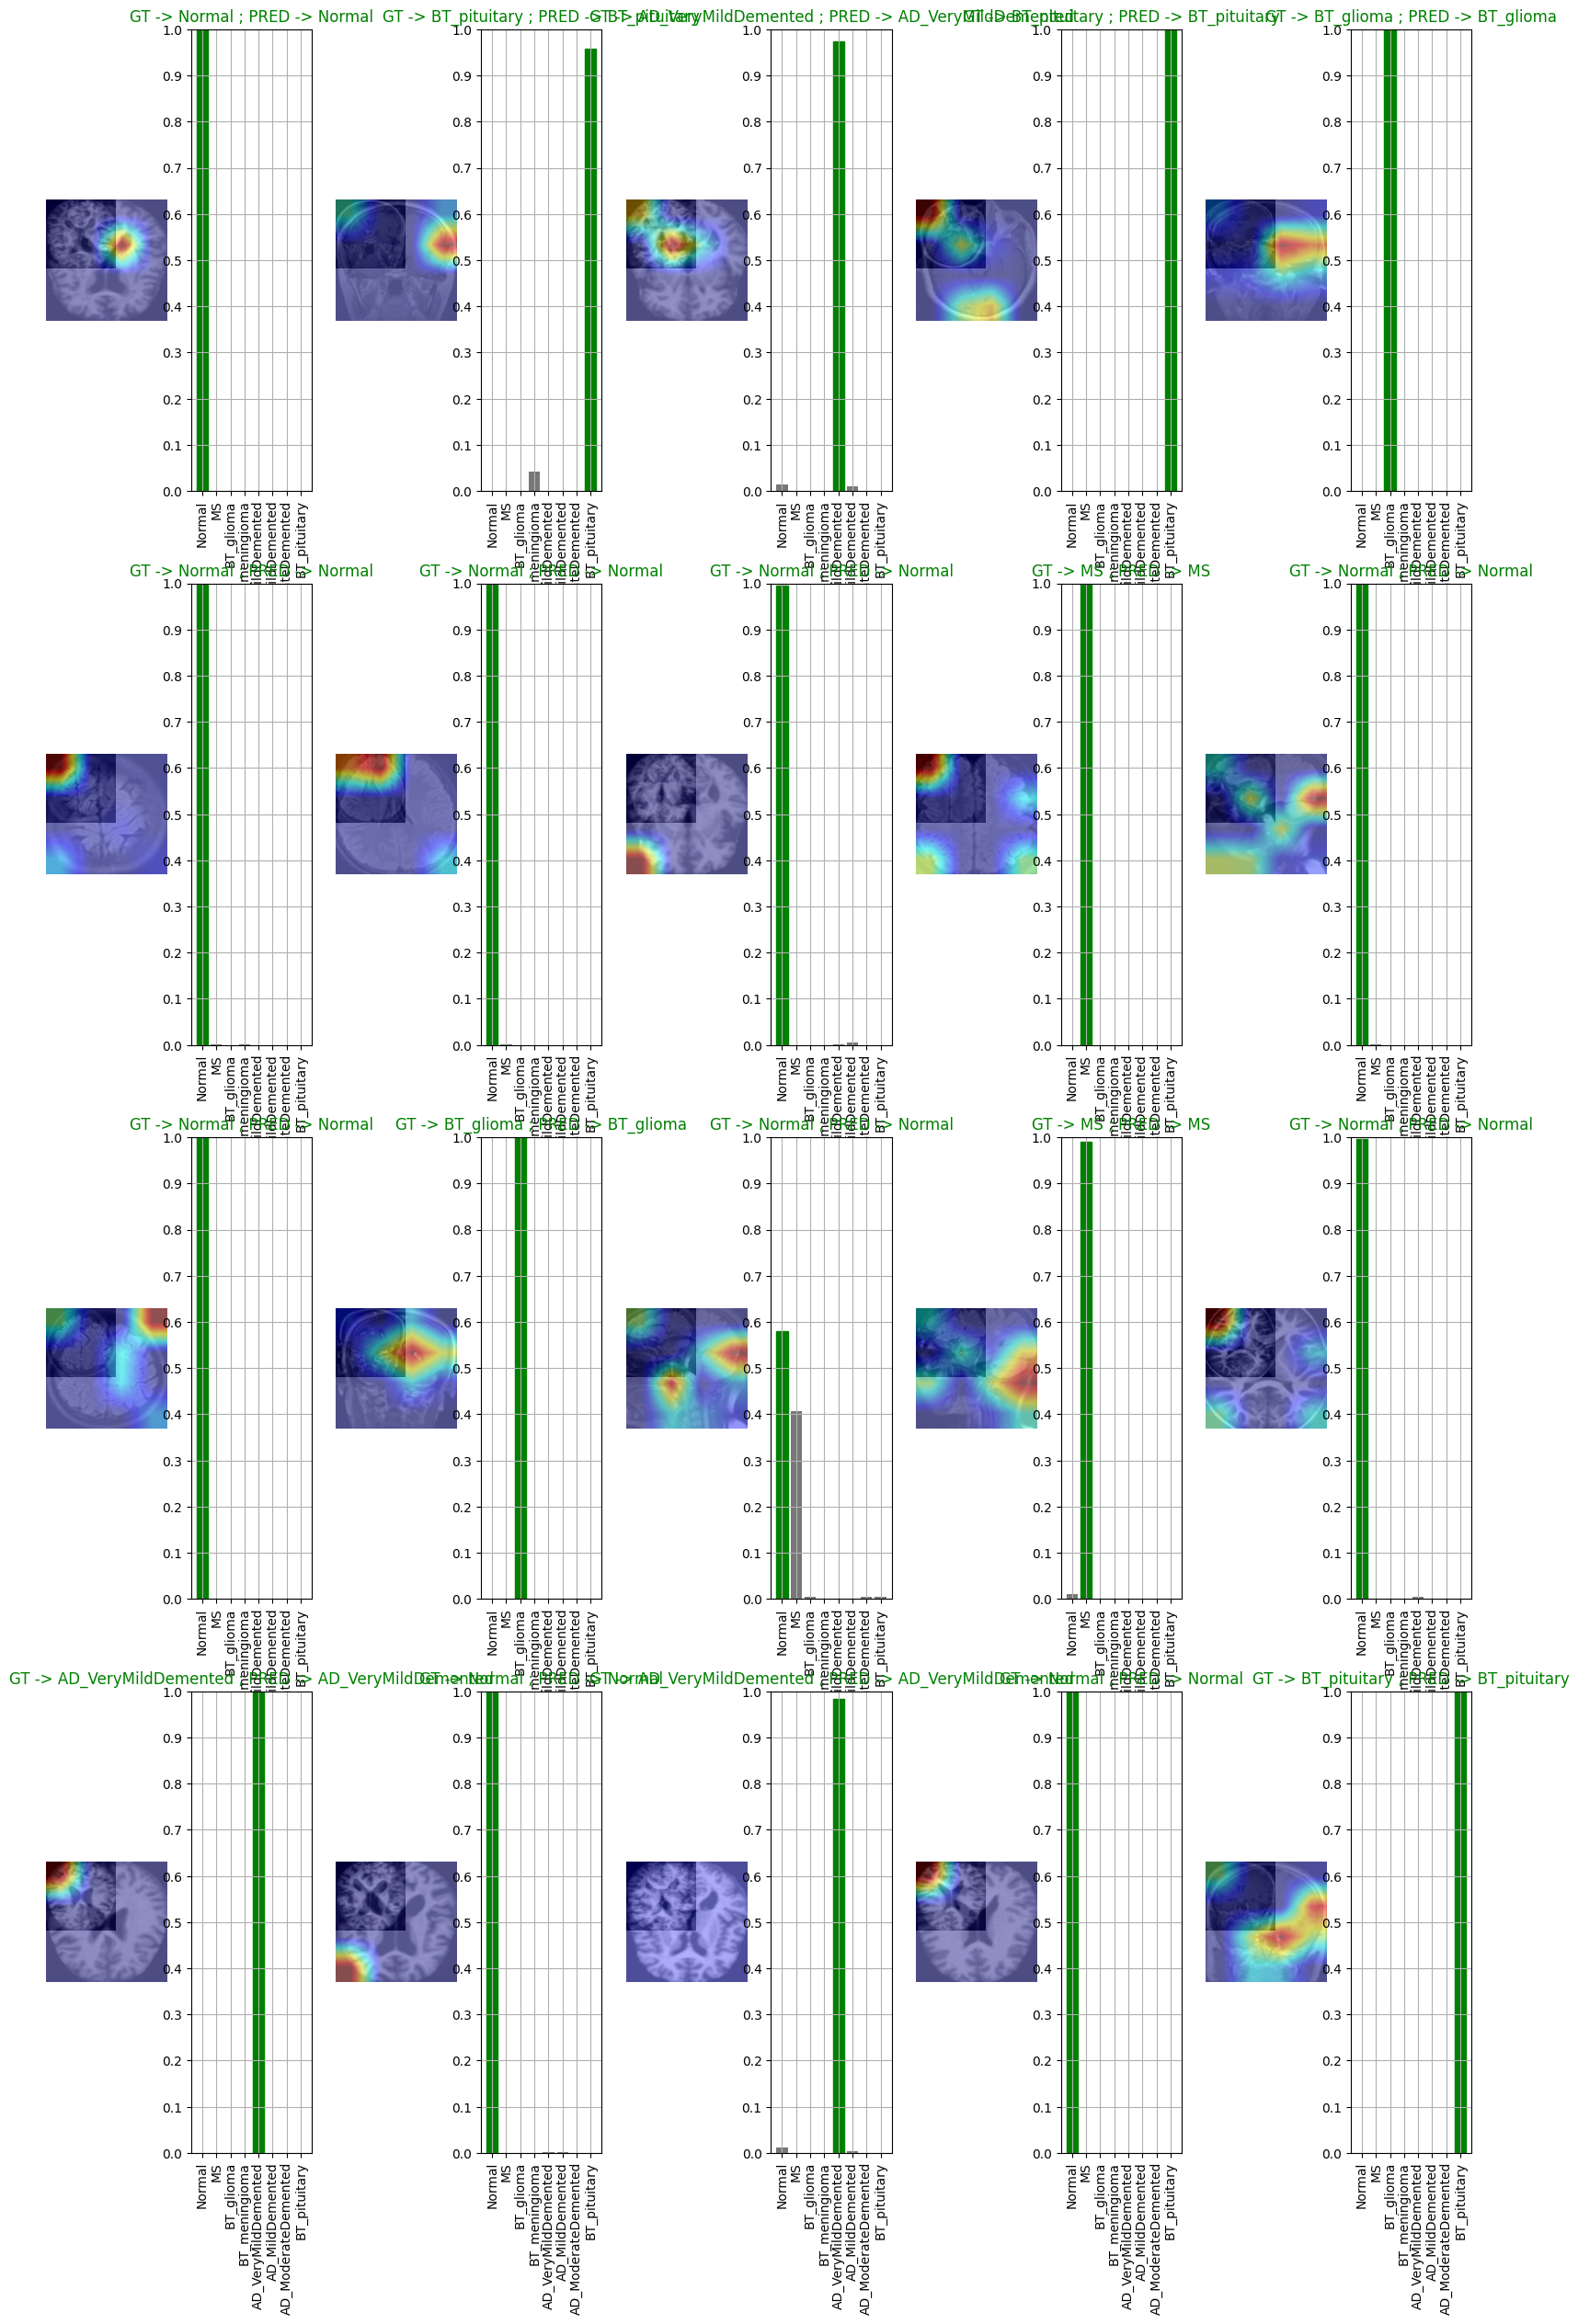

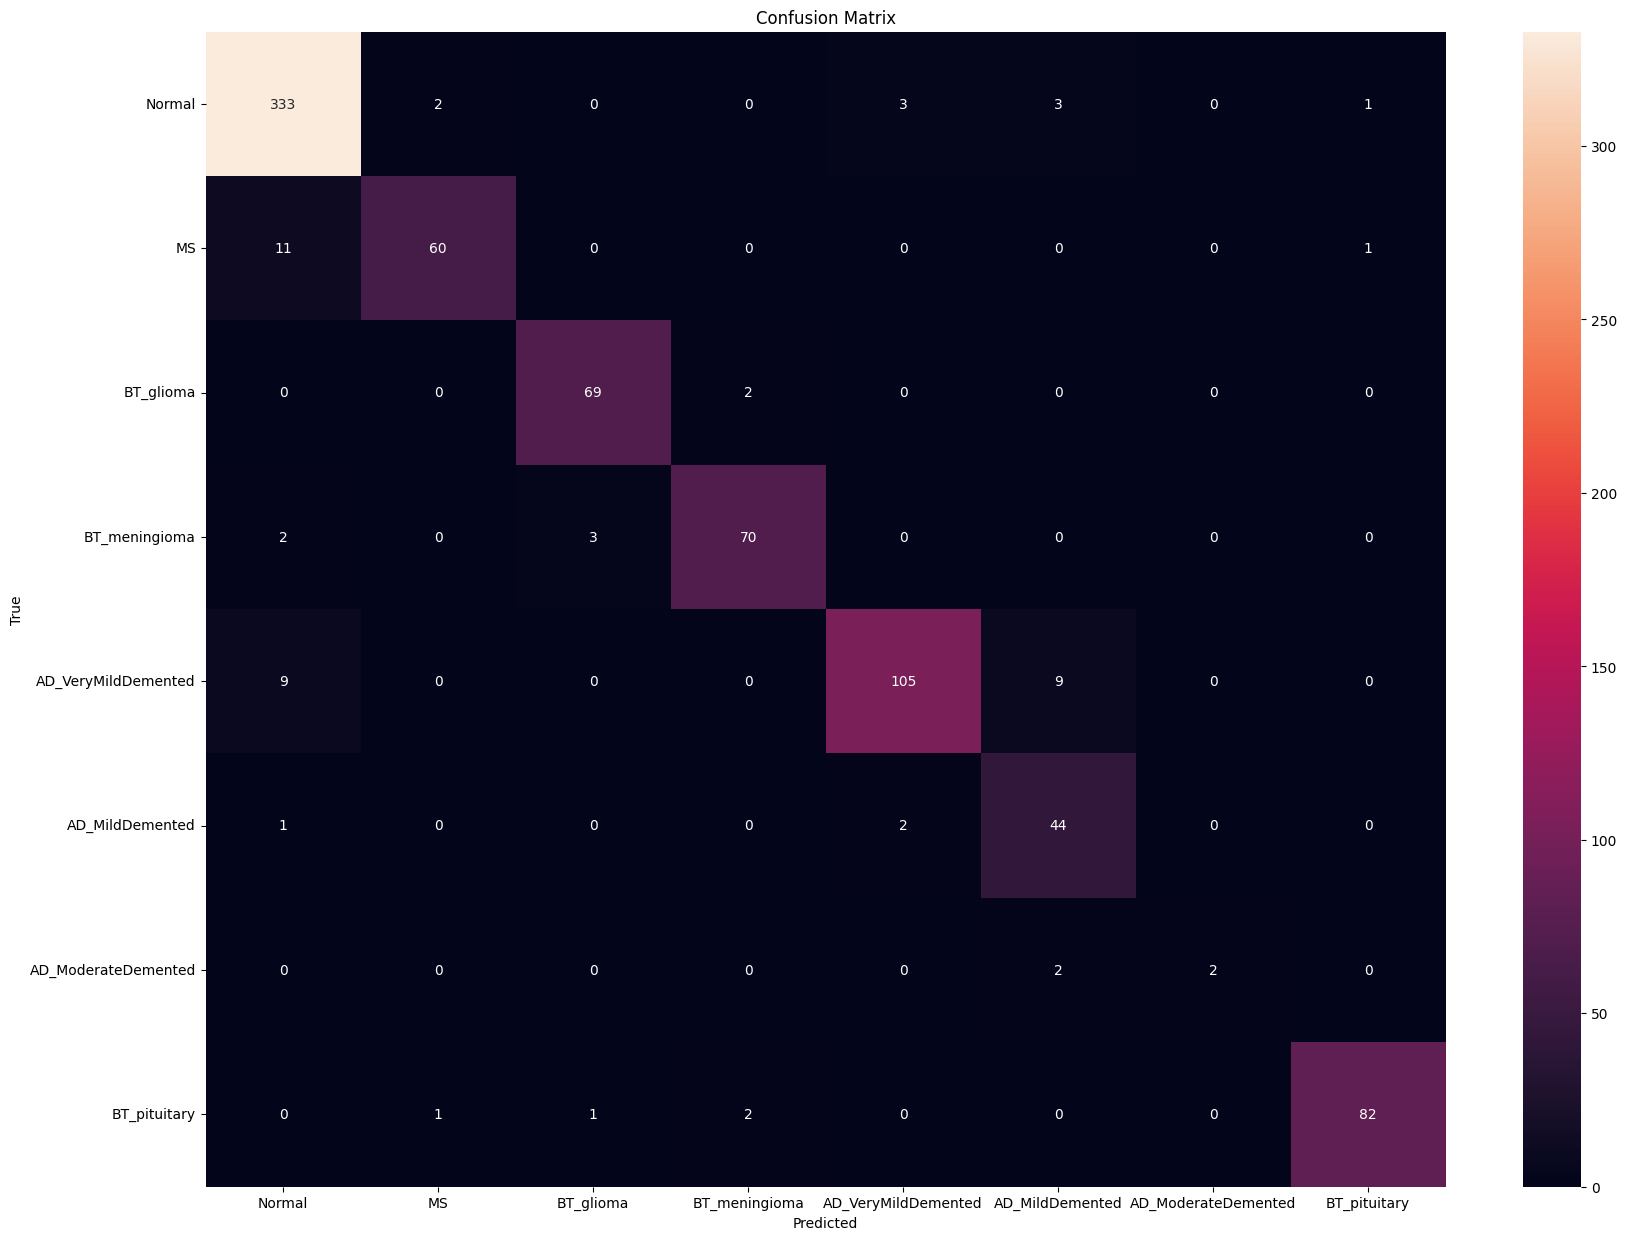

In [50]:
class explainable_model:
    def __init__(self, model, device, class_name = None, im_size = 224, mean = mean, std = std):
        self.denormalize = Denormalize(mean, std)
        self.model = model
        self.device = device
        self.class_names = class_name
        self.im_size = im_size
        self.model.eval()
        self.f1_metric = torchmetrics.F1Score(
            task = "multiclass",
            num_classes = len(classes)
        ).to(self.device)

    def tensor_to_image(self, tensor):
        tensor = self.denormalize(tensor)
        tensor = tensor.permute(1, 2, 0)  # Convert from CxHxW to HxWxC
        return (tensor.cpu().numpy() * 255).astype(np.uint8)

    def plot_probs(self, outputs, labels, class_names):
        probs = torch.nn.functional.softmax(outputs, dim = 1)
        pred_class = torch.argmax(probs, dim = 1)

        plt.grid()
        plt.xticks(range(len(class_names)), class_names, rotation = "vertical")
        plt.yticks(np.arange(0.0, 1.1, 0.1))
        bars = plt.bar(
            range(len(class_names)),
            [p.item() for p in probs[0]],
            color = "#777777"
        )

        plt.ylim([0, 1])
        if pred_class.item() == labels:
            bars[pred_class.item()].set_color("green")
        else:
            bars[pred_class.item()].set_color("red")

    def generate_gradcam(self, image_tensor):
        cam = GradCAMPlusPlus(
            model = self.model,
            target_layers = [self.model.features[-1]],
            use_cuda = self.device == "cuda"
        )

        grayscale_cam = cam(input_tensor = image_tensor.unsqueeze(0))[0,:]
        return grayscale_cam

    def infer_and_visualize(self, test_dl, num_images = 5, rows = 2):
        preds, images, lbls, logits = [], [], [], []

        accuracy, count = 0, 1
        with torch.no_grad():
            for idx, batch in tqdm(enumerate(test_dl), desc = "Inference"):
                image, label = TrainValidation.to_device(batch, device = self.device)
                logit = self.model(image)
                pred_class = torch.argmax(logit, dim=1)

                accuracy += (pred_class == label).sum().item()
                self.f1_metric.update(logit, label)

                images.append(image[0])
                logits.append(logit[0])
                preds.append(pred_class[0].item())
                lbls.append(label[0].item())

        print(f"Accuracy of model on test data --> {(accuracy / len(test_dl.dataset)):.3f}")
        print(f"F1 score of model on test data -> {(self.f1_metric.compute().item()):.3f}")

        plt.figure(figsize=(20,30))
        indices = [random.randint(0, len(images) - 1) for _ in range(num_images)]

        for idx, index in enumerate(indices):
            im = self.tensor_to_image(images[index].squeeze())
            pred_idx = preds[index]
            label_idx = lbls[index]

            plt.subplot(rows, 2 * num_images // rows, count)
            count += 1
            plt.imshow(im, cmap = "gray")
            plt.axis("off")

            # GradCAM visualization
            grayscale_cam = self.generate_gradcam(images[index])
            visualization = show_cam_on_image(im/255, grayscale_cam, image_weight = 0.4, use_rgb = True)

            plt.imshow(cv2.resize(visualization, (self.im_size, self.im_size), interpolation = cv2.INTER_LINEAR), alpha = 0.7, cmap = "jet")
            plt.axis("off")

            # prediction prob array
            logi = logits[index]
            if logi.dim() == 1:
                logi = logi.unsqueeze(0)

            plt.subplot(rows, 2*num_images // rows, count)
            count  += 1
            self.plot_probs(logi, label_idx, self.class_names)

            if self.class_names:
                label_name = self.class_names[label_idx]
                pred_name = self.class_names[pred_idx]
                color = "green" if label_name == pred_name else "red"
                plt.title(f"GT -> {label_name} ; PRED -> {pred_name}", color=color)

        plt.figure(figsize=(20, 15))
        cm = confusion_matrix(lbls, preds)
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()


inference_visualizer = explainable_model(
    model=model,
    device=device,
    class_name=list(classes.keys()),
    im_size=224
)

inference_visualizer.infer_and_visualize(test_dl, num_images = 20, rows = 4)

